# DeepPCB 데이터셋 살펴보기

모델을 만들기 전에 데이터가 어떻게 생겼는지 확인해보는 노트북입니다.

- 보드 이미지와 결함 어노테이션이 어떻게 생겼는지
- 결함 종류별 개수가 얼마나 되는지
- 패치 크기를 64x64로 정해도 되는지 (결함 박스 크기 분포 확인)


In [1]:
import os
import glob
import collections

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않게. 환경에 맞게 경로 수정)
for font_path in glob.glob('/usr/share/fonts/truetype/nanum/Nanum*.ttf'):
    fm.fontManager.addfont(font_path)
if any('NanumGothic' == f.name for f in fm.fontManager.ttflist):
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

PCB_ROOT = '../data/DeepPCB/PCBData'

def load_split(name):
    items = []
    with open(os.path.join(PCB_ROOT, name)) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                items.append((parts[0].replace('.jpg', '_test.jpg'), parts[1]))
    return items

train_items = load_split('trainval.txt')
test_items = load_split('test.txt')
print(f'학습용 보드: {len(train_items)}장 / 테스트용 보드: {len(test_items)}장')

학습용 보드: 1000장 / 테스트용 보드: 500장


## 1. 보드 이미지와 어노테이션 확인

테스트 이미지(결함 있음)와 템플릿 이미지(결함 없음)가 쌍으로 제공됩니다.
어노테이션은 `x1 y1 x2 y2 type` 형식이고, 결함 위치를 빨간 박스로 그려보면 아래와 같습니다.

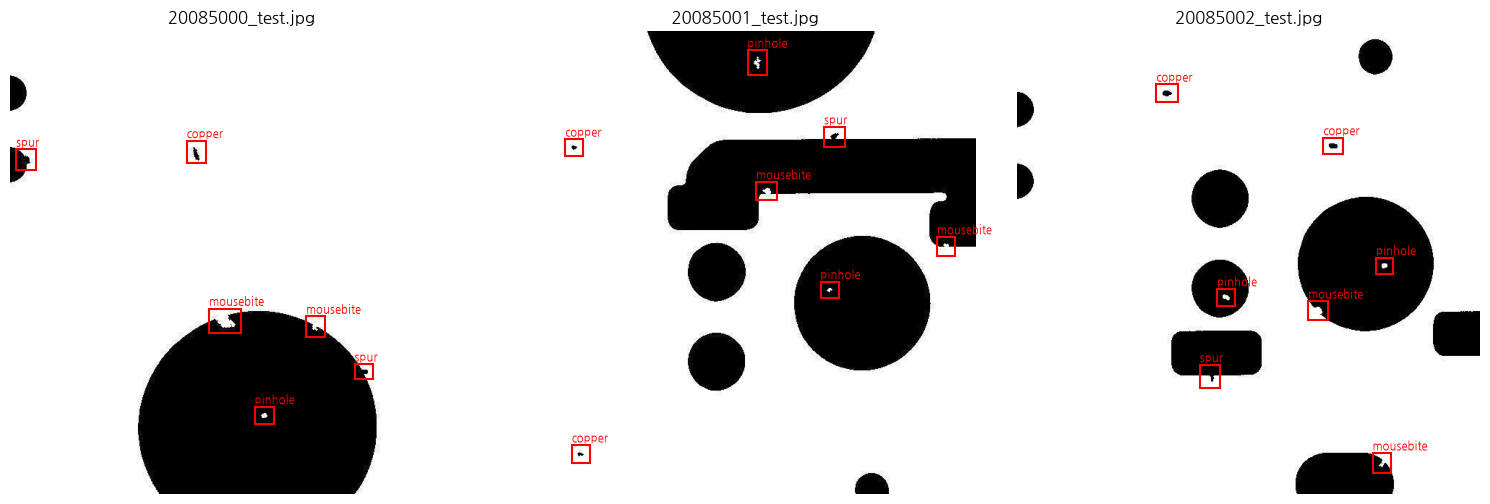

In [2]:
CLASS_NAMES = ['normal', 'open', 'short', 'mousebite', 'spur', 'copper', 'pinhole']

def load_boxes(ann_rel):
    boxes = []
    with open(os.path.join(PCB_ROOT, ann_rel)) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 5:
                boxes.append(tuple(map(int, parts[:5])))
    return boxes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (img_rel, ann_rel) in zip(axes, train_items[:3]):
    img = Image.open(os.path.join(PCB_ROOT, img_rel))
    boxes = load_boxes(ann_rel)
    ax.imshow(img, cmap='gray')
    for (x1, y1, x2, y2, t) in boxes:
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='red', linewidth=1.5))
        ax.text(x1, y1 - 5, CLASS_NAMES[t], color='red', fontsize=8)
    ax.set_title(os.path.basename(img_rel))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. 결함 종류별 분포

6종류 결함이 비교적 고르게 들어있는지 확인합니다.

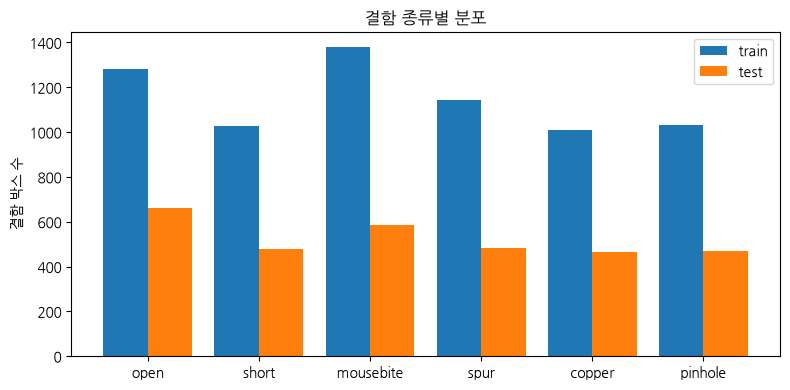

총 결함 박스: train 6873개, test 3140개
보드 1장당 평균 결함 수: 6.7개


In [3]:
counts = {'train': collections.Counter(), 'test': collections.Counter()}
box_sizes = []
for split, items in [('train', train_items), ('test', test_items)]:
    for _, ann_rel in items:
        for (x1, y1, x2, y2, t) in load_boxes(ann_rel):
            counts[split][t] += 1
            box_sizes.append((x2 - x1, y2 - y1))

labels = CLASS_NAMES[1:]
train_vals = [counts['train'][i] for i in range(1, 7)]
test_vals = [counts['test'][i] for i in range(1, 7)]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, train_vals, width=0.4, label='train')
ax.bar(x + 0.2, test_vals, width=0.4, label='test')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('결함 박스 수')
ax.legend()
ax.set_title('결함 종류별 분포')
plt.tight_layout()
plt.show()

print(f'총 결함 박스: train {sum(train_vals)}개, test {sum(test_vals)}개')
print(f'보드 1장당 평균 결함 수: {(sum(train_vals) + sum(test_vals)) / (len(train_items) + len(test_items)):.1f}개')

## 3. 결함 박스 크기 분포

패치 크기를 정하기 위해 결함 박스의 가로/세로 크기 분포를 확인합니다.

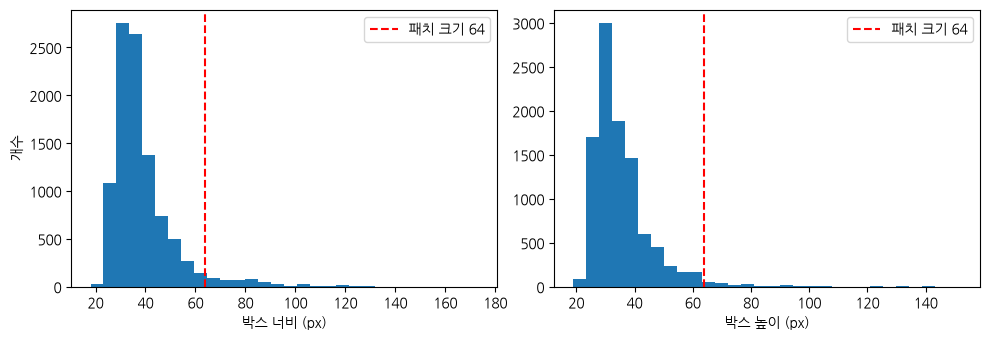

박스 너비: 평균 38.9px, 최대 173px / 박스 높이: 평균 35.7px, 최대 152px
64px보다 큰 박스 비율: 6.5%


In [4]:
ws = np.array([w for w, h in box_sizes])
hs = np.array([h for w, h in box_sizes])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(ws, bins=30)
axes[0].axvline(64, color='red', linestyle='--', label='패치 크기 64')
axes[0].set_xlabel('박스 너비 (px)')
axes[0].set_ylabel('개수')
axes[0].legend()
axes[1].hist(hs, bins=30)
axes[1].axvline(64, color='red', linestyle='--', label='패치 크기 64')
axes[1].set_xlabel('박스 높이 (px)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'박스 너비: 평균 {ws.mean():.1f}px, 최대 {ws.max()}px / 박스 높이: 평균 {hs.mean():.1f}px, 최대 {hs.max()}px')
print(f'64px보다 큰 박스 비율: {((ws > 64) | (hs > 64)).mean() * 100:.1f}%')

## 4. 추출한 패치 확인

`data/prepare_patches.py`로 만든 64x64 패치를 클래스별로 몇 장씩 봅니다.

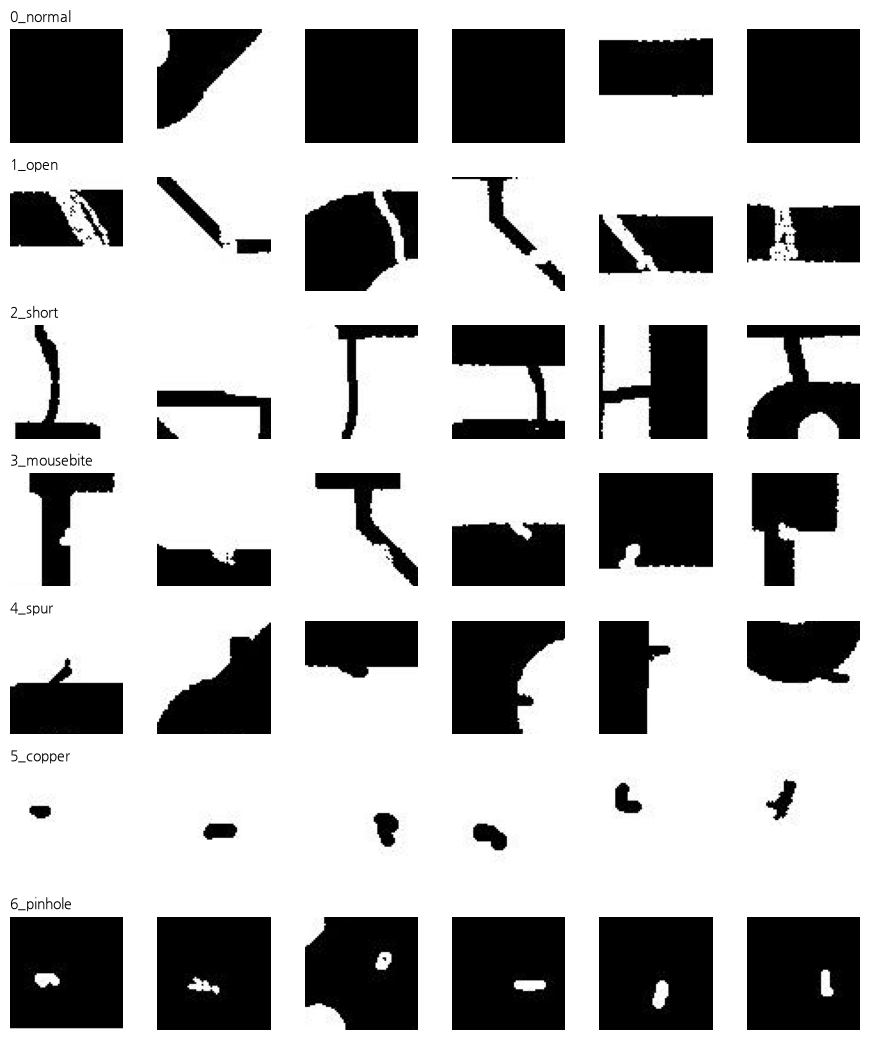

학습 패치 수: {'0_normal': 6000, '1_open': 1283, '2_short': 1028, '3_mousebite': 1379, '4_spur': 1142, '5_copper': 1010, '6_pinhole': 1031}


In [5]:
PATCH_DIR = '../data/patches/train'
patch_classes = sorted(os.listdir(PATCH_DIR))

fig, axes = plt.subplots(len(patch_classes), 6, figsize=(9, 10.5))
for row, cls in enumerate(patch_classes):
    files = sorted(glob.glob(os.path.join(PATCH_DIR, cls, '*.png')))[:6]
    for col in range(6):
        ax = axes[row][col]
        ax.imshow(Image.open(files[col]), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, loc='left', fontsize=10)
n_per_class = {cls: len(os.listdir(os.path.join(PATCH_DIR, cls))) for cls in patch_classes}
plt.tight_layout()
plt.show()
print('학습 패치 수:', n_per_class)

## 정리

- 보드 이미지는 640x640 흑백이고, 결함 위치가 박스로 어노테이션되어 있다.
- 결함 6종이 학습/테스트 모두에서 비교적 고르게 분포한다. (보드 1장당 평균 6~7개)
- 결함 박스는 대부분 64px 안에 들어와서, 패치 크기는 64x64로 정했다.
- 결함 패치는 박스 중심에서 ±16px 랜덤 오프셋을 줘서 잘랐다. 항상 정중앙에 결함이 오게
  자르면 슬라이딩 윈도우(stride 32)에서 결함이 윈도우 가장자리에 걸리는 경우를 잘 못 잡는다.
  (stride 32면 결함 중심이 윈도우 중심에서 최대 ±16px 벗어날 수 있어서 범위를 16으로 맞춤)
- 정상 패치는 결함 박스와 겹치지 않는 위치에서 이미지당 6장씩 랜덤 크롭했다.
  (정상:결함 비율이 대략 1:1이 되도록 개수를 맞춤)
- 배경이 이진화에 가까운 흑백이라 조명 변화 부담은 적지만, 그만큼 패턴(배선) 모양이
  다양해서 정상 패치도 종류가 많다. 데이터를 늘리는 것보다 결함 주변 문맥이 잘 잡히는지가
  중요해 보인다.